In [2]:
###Load packages###
import pandas as pd
import os
import ast
from scipy import stats
from matplotlib import pyplot as plt
from scipy.stats import pearsonr
from scipy.stats import spearmanr
from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind
import numpy as np

###Load cleaned dataset###

#Set file paths
topdir = '/Users/sm6511/Desktop/Prediction-Accomodation-Exp'
study = 'Study1.0'
cleandir = os.path.join(topdir, f'data/{study}/Cleaned')
outputdir = os.path.join(topdir, f'Analysis/Plots/{study}')
outputdirCombined = os.path.join(topdir, f'data/Combined')

#Read in cleaned data (from cleaning scripts)
accommodate_path = os.path.join(cleandir, f'{study}Accommodate.csv')
predict_path   = os.path.join(cleandir, f'{study}Predict.csv')

df_accommodate = pd.read_csv(accommodate_path)
df_predict   = pd.read_csv(predict_path)

df_accommodate['task'] = 'accommodate'
df_predict['task']   = 'predict'


print("Accomodate columns:", df_accommodate.columns.tolist())
print("Predict columns:", df_predict.columns.tolist())


Accomodate columns: ['participant', 'free_texts', 'feedback', 'food_amount', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_tail', 'training_shape', 'training_color', 'testing_categories', 'conditionOrder', 'training_image_order', 'attention_check', 'relevant_dim_1', 'relevant_dim_2', 'irrelevant_dim', 'color_high', 'color_low', 'shape_high', 'shape_low', 'tail_high', 'tail_low', 'shape_discrete_slider.response', 'shape_direction_slider.response', 'shape_continuous_slider.response', 'color_discrete_slider.response', 'color_direction_slider.response', 'color_continuous_slider.response', 'tail_discrete_slider.response', 'tail_direction_slider.response', 'tail_continuous_slider.response', 'task']
Predict columns: ['participant', 'training_responses', 'food_amount', 'error', 'feedback', 'trial_stop_time', 'testing_image_order', 'testing_responses', 'training_categories', 'training_tail', 'training_shape', 'training_color', 'testing_categorie

In [3]:
#Converting string representations of lists back to lists

def parse_list_column(x):
    """take column entries that are strings representing lists and convert them to actual lists"""
    if pd.isna(x):
        return []
    if isinstance(x, list):
        return x
    if isinstance(x, str):
        x = x.strip()
        if x.startswith('[') and x.endswith(']'):
            return ast.literal_eval(x)
        else:
            return [x]
    return []
for col in ['training_tail', 'training_shape', 'training_color', 'training_image_order', 'training_categories', 'testing_categories']:
    df_accommodate[col] = df_accommodate[col].apply(parse_list_column)
    df_predict[col]   = df_predict[col].apply(parse_list_column)

df_accommodate['testing_responses'] = df_accommodate['testing_responses'].apply(ast.literal_eval)
df_accommodate['food_amount'] = df_accommodate['food_amount'].apply(ast.literal_eval)
df_accommodate['testing_image_order'] = df_accommodate['testing_image_order'].apply(ast.literal_eval)
df_predict['testing_responses'] = df_predict['testing_responses'].apply(ast.literal_eval)
df_predict['food_amount'] = df_predict['food_amount'].apply(ast.literal_eval)
df_predict['testing_image_order'] = df_predict['testing_image_order'].apply(ast.literal_eval)
#Combine the dataframes and create an arbitrary column for participant numbering (the yoked orders are already stored in 'conditionOrder')
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)
df_combined['participant'] = range(1, len(df_combined) + 1)



In [4]:
# Load explanation coding
coding_path = os.path.join(
    topdir,
    "data/Combined/explanationcodes/Explanation_Coding_Study1.csv"
)

df_coding = pd.read_csv(coding_path)

# Drop empty rows 
df_coding = df_coding.dropna(subset=["participant"]).copy()

# Convert participant IDs (unique condition order identifiers)
df_coding["participant"] = df_coding["participant"].astype(int)
df_accommodate["participant"] = df_accommodate["participant"].astype(int)

# Treat blank cells as 0, coded cells as 1
coding_cols = ["None", "Causal_Explanation", 
               "Color", "Tail", "Shape", 'All']

for col in coding_cols:
    df_coding[col] = df_coding[col].fillna(0)
    df_coding[col] = df_coding[col].replace("", 0)
    df_coding[col] = df_coding[col].astype(int)


# Category Mapping:
# None / Explanation / Causal_Explanation only -> none
# Color -> Color
# Tail -> Tail
# stripes+Tail -> both

# Broad causal flag: marked causal OR feature-specific causal
df_coding["causal_color"] = (
    df_coding["Color"].eq(1)
    | df_coding["All"].eq(1)
)

df_coding["causal_tail"] = (
    df_coding["Tail"].eq(1)
    | df_coding["All"].eq(1)
)


df_coding["causal_shape"] = (
    df_coding["Shape"].eq(1)
    | df_coding["All"].eq(1)
)

# Broad causal flag
df_coding["has_causal_explanation"] = (
    df_coding["Causal_Explanation"].eq(1)
    | df_coding["causal_color"]
    | df_coding["causal_tail"]
    | df_coding["causal_shape"]
)

df_accommodate = df_accommodate.merge(
    df_coding[
        [
            "participant",
            "has_causal_explanation",
            "causal_color",
            "causal_tail",
            "causal_shape",
        ]
    ],
    on="participant",
    how="left"
)

# Participants not in coding file default to none
df_accommodate["has_causal_explanation"] = df_accommodate["has_causal_explanation"].fillna(False)
df_accommodate["causal_color"] = df_accommodate["causal_color"].fillna(False)
df_accommodate["causal_tail"] = df_accommodate["causal_tail"].fillna(False)
df_accommodate["causal_shape"] = df_accommodate["causal_shape"].fillna(False)

In [4]:
df_combined = pd.concat([df_accommodate, df_predict], ignore_index=True)

In [5]:
participant_id = 71

row = df_accommodate.loc[
    df_accommodate["participant"] == participant_id
].iloc[0]

print(f"Participant: {participant_id}")
#print(f"Explanation type: {row['explanation_type']}")
print(f"Has causal explanation: {row['has_causal_explanation']}")
print(f"Causal tail: {row['causal_tail']}")
print(f"Causal color: {row['causal_color']}")
print(f"Causal shape: {row['causal_shape']}")
print("\n--- FREE TEXTS ---\n")

import ast

free_texts = row["free_texts"]

if isinstance(free_texts, str):
    free_texts = ast.literal_eval(free_texts)

for text in free_texts:
    print(text)
    print()

Participant: 71
Has causal explanation: False
Causal tail: False
Causal color: False
Causal shape: False

--- FREE TEXTS ---

Based on the color blue, square body and straight tail

Based on the typical amount eaten by all types

Based on blue, square, curly tail

Based on blue, round, curly tail

based on round shape and curly tail

Square shape, straight tail

Based on yellow color and round shape

Based on round shape

Based on round shape

Based on round shape

Based on yellow color and square shape

Based on square shape

3 base + 1 yellow + 1 round + 1 curly tail

3 base + 1 round + 1 yellow + 4?

3 base + 1 curly tail - 2?

3 base + 1 yellow + 1 curly - 1?

3 base + 1 yellow + 1 round + 5?

3 base + 1 round + 4?

3 base + 1 round + 1 curly + 2?

3 base + 1 yellow + 1 curly - 4?

3 base + 1 curly

3 base + 1 yellow + 1?

3 base - 1?

3 base + 1 yellow + 1 round + 1 curly - 1?



In [6]:

df_combined = pd.concat(
    [df_accommodate, df_predict],
    ignore_index=True
)

df_combined['participant'] = range(1, len(df_combined) + 1)
participant_rows = []

for _, row in df_combined.iterrows():

    tail_yes = (
        1 if row['tail_discrete_slider.response'] == 'Yes' else 0
    )
    shape_yes = (
        1 if row['shape_discrete_slider.response'] == 'Yes' else 0
    )
    color_yes = (
        1 if row['color_discrete_slider.response'] == 'Yes' else 0
    )

    model_param_score = (
        tail_yes +
        shape_yes +
        color_yes
    )

    # Create 3-level explanation group
    if row['task'] == 'predict':
        explanation_group = 'predictor'

    elif row['has_causal_explanation'] == True:
        explanation_group = 'causal_explainer'

    else:
        explanation_group = 'non_explainer'

    participant_rows.append({
        'participant': row['participant'],
        'task': row['task'],
        'explanation_group': explanation_group,
        'model_param_score': model_param_score,
        'conditionOrder': row['conditionOrder'],
        'overfit': model_param_score == 3,
        'irrelevant_dim': row['irrelevant_dim']
    })

df_params = pd.DataFrame(participant_rows)
df_params.to_csv(
    os.path.join(
        outputdirCombined,
        "df_params_by_explanation_for_R-Study1.csv"
    ),
    index=False
)
contingency = pd.crosstab(
    df_params['explanation_group'],
    df_params['overfit']
)

print("\nContingency table:")
print(contingency)

chi2, p, dof, expected = chi2_contingency(contingency)

print("\nOmnibus chi-square:")
print(f"Chi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

print("\nExpected counts:")
print(
    pd.DataFrame(
        expected,
        index=contingency.index,
        columns=contingency.columns
    )
)


Contingency table:
overfit            False  True 
explanation_group              
causal_explainer       7      1
non_explainer         71     71
predictor             80     70

Omnibus chi-square:
Chi-square = 4.326
df = 2
p-value = 0.1150

Expected counts:
overfit                False      True 
explanation_group                      
causal_explainer    4.213333   3.786667
non_explainer      74.786667  67.213333
predictor          79.000000  71.000000


In [20]:
contingency_all = pd.crosstab(
    df_params['explanation_group'],
    df_params['model_param_score']
)

# Put groups in desired order
contingency_all = contingency_all.reindex([
    'predictor',
    'causal_explainer',
    'non_explainer'
])

print("\nObserved counts:")
print(contingency_all)

# Chi-square test
chi2, p, dof, expected = chi2_contingency(contingency_all)

print(f"\nChi-square = {chi2:.3f}")
print(f"df = {dof}")
print(f"p-value = {p:.4f}")

# Expected counts
expected_df = pd.DataFrame(
    expected,
    index=contingency_all.index,
    columns=contingency_all.columns
)

print("\nExpected counts:")
print(expected_df)


Observed counts:
model_param_score  0   1   2   3
explanation_group               
predictor          8  16  56  70
causal_explainer   2   2   3   1
non_explainer      6  14  51  71

Chi-square = 10.076
df = 6
p-value = 0.1215

Expected counts:
model_param_score         0          1          2          3
explanation_group                                           
predictor          8.000000  16.000000  55.000000  71.000000
causal_explainer   0.426667   0.853333   2.933333   3.786667
non_explainer      7.573333  15.146667  52.066667  67.213333


In [18]:
# Create map from feature response labels to internal short codes
shape_map = {
    'square': 's',
    'circular': 'c'
}

color_map = {
    'blue': 'b',
    'yellow': 'y'
}

tail_map = {
    'curly': 't',
    'straight': 'n'
}


feature_maps = {
    'shape': shape_map,
    'color': color_map,
    'tail': tail_map
}


# Compute feature importance scores

def compute_feature_importance_from_df(df):
    """
    Compute numeric feature-importance scores from -7 to 7.

    A score of 0 indicates that the participant said the feature was not
    relevant, did not respond, or selected a direction that could not be
    matched to the stored high/low feature values.
    """

    df = df.copy()
    features = ["shape", "color", "tail"]

    def normalize_str(value):
        """Strip whitespace, collapse repeated spaces, and lowercase strings."""
        if isinstance(value, str):
            return " ".join(value.split()).lower()
        return ""

    def compute_row_importance(row, feat):
        disc = row[f"{feat}_discrete_slider.response"]
        direction = row[f"{feat}_direction_slider.response"]
        continuous = row[f"{feat}_continuous_slider.response"]

        # If the participant said the feature was not relevant,
        # or did not answer, importance is zero
        if disc == "No" or pd.isna(disc):
            return 0.0

        # Missing continuous response defaults to zero
        cont_val = float(continuous) if not pd.isna(continuous) else 0.0

        mapping = feature_maps.get(feat, {})

        direction_norm = normalize_str(direction)
        internal_direction = mapping.get(direction_norm)

        high_val = normalize_str(row[f"{feat}_high"])
        low_val = normalize_str(row[f"{feat}_low"])

        # Positive if the selected direction matches the true high value
        if internal_direction == high_val:
            sign = 1

        # Negative if the selected direction matches the true low value
        elif internal_direction == low_val:
            sign = -1

        # Unmatched or missing response
        else:
            sign = 0
            cont_val = 0.0

        return cont_val * sign

    for feat in features:
        df[f"{feat}_importance"] = df.apply(
            lambda row: compute_row_importance(row, feat),
            axis=1,
        )

    return df


df_combined = compute_feature_importance_from_df(df_combined)


# Create explanation groups:
# predict
# accommodate_causal
# accommodate_none

df_combined["task_explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),
        (
            df_combined["task"].eq("accommodate")
            & df_combined["has_causal_explanation"].fillna(False)
        ),
        (
            df_combined["task"].eq("accommodate")
            & ~df_combined["has_causal_explanation"].fillna(False)
        ),
    ],
    [
        "predict",
        "accommodate_causal",
        "accommodate_none",
    ],
    default=pd.NA,
)


# Reshape to long format:
# one row per participant × feature dimension

cols_to_keep = [
    "participant",
    "task",
    "task_explanation_group",
    "tail_importance",
    "color_importance",
    "shape_importance",
    "has_causal_explanation",
    "causal_tail",
    "causal_color",
    "causal_shape",
    "relevant_dim_1",
    "relevant_dim_2",
    "irrelevant_dim",
    "color_high",
    "shape_high",
    "tail_discrete_slider.response",
    "shape_discrete_slider.response",
]

df_long = df_combined[cols_to_keep].copy()

df_long = df_long.melt(
    id_vars=[
        "participant",
        "task",
        "task_explanation_group",
        "has_causal_explanation",
        "causal_tail",
        "causal_color",
        "causal_shape",
        "relevant_dim_1",
        "relevant_dim_2",
        "irrelevant_dim",
        "color_high",
        "shape_high",
        "tail_discrete_slider.response",
        "shape_discrete_slider.response",
    ],
    value_vars=[
        "tail_importance",
        "color_importance",
        "shape_importance",
    ],
    var_name="feature_dimension",
    value_name="feature_importance",
)

# Simplify feature-dimension names
df_long["feature_dimension"] = (
    df_long["feature_dimension"]
    .str.replace("_importance", "", regex=False)
)


# Create row-level indicator:
# Did this participant provide a causal explanation for this specific feature?

df_long["had_causal_explanation_for_feature"] = np.select(
    [
        df_long["feature_dimension"].eq("tail"),
        df_long["feature_dimension"].eq("color"),
        df_long["feature_dimension"].eq("shape"),
    ],
    [
        df_long["causal_tail"].fillna(False),
        df_long["causal_color"].fillna(False),
        df_long["causal_shape"].fillna(False),
    ],
    default=False,
).astype(bool)

# Predictors should always be False
df_long["had_causal_explanation_for_feature"] = (
    df_long["had_causal_explanation_for_feature"]
    & df_long["task"].eq("accommodate")
)


# Create the three-level grouping:
# predictor
# explainer
# non_explainer

df_long["feature_explanation_group"] = np.select(
    [
        df_long["task"].eq("predict"),
        (
            df_long["task"].eq("accommodate")
            & df_long["had_causal_explanation_for_feature"]
        ),
        (
            df_long["task"].eq("accommodate")
            & ~df_long["had_causal_explanation_for_feature"]
        ),
    ],
    [
        "predictor",
        "explainer",
        "non_explainer",
    ],
    default=pd.NA,
)


# Determine whether each feature was relevant or irrelevant

df_long["feature_relevance"] = np.where(
    df_long.apply(
        lambda row: row["feature_dimension"]
        in [row["relevant_dim_1"], row["relevant_dim_2"]],
        axis=1,
    ),
    "relevant",
    "irrelevant",
)


# Optional checks


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_18860/2479975981.py:103: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_18860/2479975981.py:107: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_18860/2479975981.py:187: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in 

In [7]:
print(
    df_long.groupby(
        ["feature_dimension", "feature_explanation_group"],
        dropna=False,
    ).size()
)

print(
    df_long.loc[
        df_long["participant"].eq(31),
        [
            "participant",
            "task",
            "feature_dimension",
            "causal_color",
            "causal_tail",
            "causal_shape",
            "had_causal_explanation_for_feature",
            "feature_explanation_group",
            "feature_importance",
            "feature_relevance",
        ],
    ].sort_values("feature_dimension")
)

feature_dimension  feature_explanation_group
color              non_explainer                150
                   predictor                    150
shape              explainer                      6
                   non_explainer                144
                   predictor                    150
tail               non_explainer                150
                   predictor                    150
dtype: int64
     participant         task feature_dimension causal_color causal_tail  \
359           31  accommodate             color        False       False   
563           31      predict             color          NaN         NaN   
659           31  accommodate             shape        False       False   
863           31      predict             shape          NaN         NaN   
59            31  accommodate              tail        False       False   
263           31      predict              tail          NaN         NaN   

    causal_shape  had_causal_explanation_for_

In [8]:
df_long.groupby(
    ["task",  "had_causal_explanation_for_feature"],
    dropna=False
).size()

task         had_causal_explanation_for_feature
accommodate  False                                 444
             True                                    6
predict      False                                 450
dtype: int64

In [9]:
participant_summary = (
    df_long[["participant", "task", "has_causal_explanation"]]
    .drop_duplicates()
)

participant_summary["has_causal_explanation"].value_counts()

has_causal_explanation
False    142
True       8
Name: count, dtype: int64

In [10]:
df_long.groupby(
    ["task", "feature_dimension", "had_causal_explanation_for_feature"],
    dropna=False
).size()

task         feature_dimension  had_causal_explanation_for_feature
accommodate  color              False                                 150
             shape              False                                 144
                                True                                    6
             tail               False                                 150
predict      color              False                                 150
             shape              False                                 150
             tail               False                                 150
dtype: int64

In [11]:
df_long.to_csv(os.path.join(outputdirCombined, 'df_long_by_explanation_for_R-Study1.csv'), index=False)

In [12]:
# Features included in the overfitting/relevance count
features = ["tail", "color", 'shape']

discrete_cols = [
    f"{feat}_discrete_slider.response"
    for feat in features
]

# Inspect the response values before recoding
for col in discrete_cols:
    print(f"\nValues in {col}:")
    print(df_combined[col].value_counts(dropna=False))


Values in tail_discrete_slider.response:
tail_discrete_slider.response
Yes    231
No      69
Name: count, dtype: int64

Values in color_discrete_slider.response:
color_discrete_slider.response
Yes    207
No      93
Name: count, dtype: int64

Values in shape_discrete_slider.response:
shape_discrete_slider.response
Yes    240
No      60
Name: count, dtype: int64


   explanation_group  n_features_endorsed  n_participants  percentage
0          Predictor                    0               8    5.333333
1          Predictor                    1              16   10.666667
2          Predictor                    2              56   37.333333
3          Predictor                    3              70   46.666667
4      Non-explainer                    0               6    4.225352
5      Non-explainer                    1              14    9.859155
6      Non-explainer                    2              51   35.915493
7      Non-explainer                    3              71   50.000000
8          Explainer                    0               2   25.000000
9          Explainer                    1               2   25.000000
10         Explainer                    2               3   37.500000
11         Explainer                    3               1   12.500000


/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37325/2231963854.py:29: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & df_combined["has_causal_explanation"].fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37325/2231963854.py:34: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  & ~df_combined["has_causal_explanation"].fillna(False)


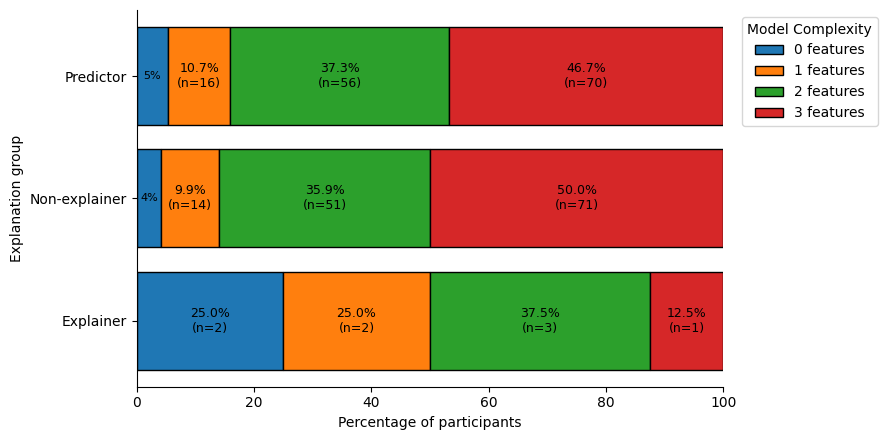

In [13]:
# Convert Yes/No response to 'does this feature matter' into 1/0 indicators
for feat in features:
    response_col = f"{feat}_discrete_slider.response"
    endorsed_col = f"{feat}_endorsed"

    df_combined[endorsed_col] = (
        df_combined[response_col]
        .astype("string")
        .str.strip()
        .str.lower()
        .eq("yes")
        .astype(int)
    )

# Total number of features judged relevant: 0, 1, 2, or 3
df_combined["n_features_endorsed"] = (
    df_combined["tail_endorsed"]
    + df_combined["color_endorsed"]
    + df_combined["shape_endorsed"]
)

# Create a new column for explanation group, based on task and causal explanation status
df_combined["explanation_group"] = np.select(
    [
        df_combined["task"].eq("predict"),

        (
            df_combined["task"].eq("accommodate")
            & df_combined["has_causal_explanation"].fillna(False)
        ),

        (
            df_combined["task"].eq("accommodate")
            & ~df_combined["has_causal_explanation"].fillna(False)
        ),
    ],
    [
        "Predictor",
        "Explainer",
        "Non-explainer",
    ],
    default=pd.NA,
)
# Create a unique identifier for each participant × task combination
df_combined["participant_task_id"] = (
    df_combined["participant"].astype(str)
    + "_"
    + df_combined["task"].astype(str)
)
overfit_df = df_combined[
    [
        "participant",
        "participant_task_id",
        "task",
        "explanation_group",
        "tail_endorsed",
        "color_endorsed",
        "shape_endorsed",
        "n_features_endorsed",
        "relevant_dim_1",
        "irrelevant_dim",
    ]
].copy()

# Plotting order
group_order = [
    "Predictor",
    "Non-explainer",
    "Explainer",
]

score_order = [0, 1, 2, 3]


# Count participants at each score within each group
overfit_percentages = (
    overfit_df
    .dropna(
        subset=[
            "explanation_group",
            "n_features_endorsed",
        ]
    )
    .groupby(
        [
            "explanation_group",
            "n_features_endorsed",
        ],
        observed=True
    )
    .agg(
        n_participants=(
            "participant_task_id",
            "nunique"
        )
    )
    .reset_index()
)


# If a group has no participants with a given score, we want to fill in that row with 0 participants
full_index = pd.MultiIndex.from_product(
    [
        group_order,
        score_order,
    ],
    names=[
        "explanation_group",
        "n_features_endorsed",
    ]
)

overfit_percentages = (
    overfit_percentages
    .set_index(
        [
            "explanation_group",
            "n_features_endorsed",
        ]
    )
    .reindex(
        full_index,
        fill_value=0
    )
    .reset_index()
)


# Calculate percentage within each explanation group
overfit_percentages["percentage"] = (
    overfit_percentages["n_participants"]
    / overfit_percentages
        .groupby("explanation_group")["n_participants"]
        .transform("sum")
    * 100
)

print(overfit_percentages)

count_wide = (
    overfit_percentages
    .pivot(
        index="explanation_group",
        columns="n_features_endorsed",
        values="n_participants"
    )
    .reindex(group_order)
    .reindex(columns=[0, 1, 2, 3], fill_value=0)
    .fillna(0)
)

# Convert long percentages table to wide format:
# one row per group, one column for each score
percentage_wide = (
    overfit_percentages
    .pivot(
        index="explanation_group",
        columns="n_features_endorsed",
        values="percentage"
    )
    .reindex(group_order)
    .reindex(columns=[0, 1, 2, 3], fill_value=0)
    .fillna(0)
)


fig, ax = plt.subplots(figsize=(9, 4.5))

left = np.zeros(len(percentage_wide))
#Plot horizontal stacked bar chart
for score in [0, 1, 2, 3]:
    percentages = percentage_wide[score].to_numpy()
    counts = count_wide[score].to_numpy()

    bars = ax.barh(
        y=percentage_wide.index,
        width=percentages,
        left=left,
        edgecolor="black",
        label=f"{score} features",
    )

    for bar, percentage, count, starting_point in zip(
        bars,
        percentages,
        counts,
        left,
    ):
        if percentage >= 8:
            ax.text(
                starting_point + percentage / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.1f}%\n(n={int(count)})",
                ha="center",
                va="center",
                fontsize=9,
            )
        elif percentage > 0:
            ax.text(
                starting_point + percentage / 2,
                bar.get_y() + bar.get_height() / 2,
                f"{percentage:.0f}%",
                ha="center",
                va="center",
                fontsize=8,
            )

    left += percentages

ax.set_xlim(0, 100)
ax.set_xlabel("Percentage of participants")
ax.set_ylabel("Explanation group")
ax.set_xticks(np.arange(0, 101, 20))
ax.invert_yaxis()

ax.legend(
    title="Model Complexity",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

In [14]:

# Average training food score for each item and participant
training_cols = [
    "participant",
    "task",
    "training_image_order",
    "food_amount",
]

df_train = df_combined[training_cols].copy()

df_train_long = (
    df_train
    .explode(
        [
            "training_image_order",
            "food_amount",
        ]
    )
    .rename(
        columns={
            "training_image_order": "item"
        }
    )
)

# Ensure food scores are numeric
df_train_long["food_amount"] = pd.to_numeric(
    df_train_long["food_amount"],
    errors="coerce",
)

avg_food_train = (
    df_train_long
    .groupby(
        [
            "participant",
            "task",
            "item",
        ],
        as_index=False,
    )["food_amount"]
    .mean()
)


# ------------------------------------------------------------
# Reshape test responses to one row per participant × test item
# ------------------------------------------------------------

testing_cols = [
    "participant",
    "task",
    "testing_image_order",
    "testing_responses",
    "relevant_dim_1",
    "relevant_dim_2",
    "irrelevant_dim",
    "color_high",
    "tail_high",
    "shape_high",
    "has_causal_explanation",
    "causal_color",
    "causal_tail",
    "causal_shape",
]

df_test = df_combined[testing_cols].copy()

df_test_long = (
    df_test
    .explode(
        [
            "testing_image_order",
            "testing_responses",
        ]
    )
    .rename(
        columns={
            "testing_image_order": "item"
        }
    )
)

# Ensure test responses are numeric
df_test_long["testing_responses"] = pd.to_numeric(
    df_test_long["testing_responses"],
    errors="coerce",
)


# ------------------------------------------------------------
# Merge test scores with average training food
# ------------------------------------------------------------

df_merged = df_test_long.merge(
    avg_food_train,
    on=[
        "participant",
        "task",
        "item",
    ],
    how="left",
    validate="many_to_one",
)


# Compute signed and absolute prediction error
df_merged["error"] = (
    df_merged["testing_responses"]
    - df_merged["food_amount"]
)

df_merged["abs_error"] = df_merged["error"].abs()


# ------------------------------------------------------------
# Extract the feature values from each item code (structued as tail_color_shape)
# ------------------------------------------------------------

# Assumes item names have the structure:
# tail_color_shape
df_merged[
    [
        "tail",
        "color",
        "shape",
    ]
] = (
    df_merged["item"]
    .astype(str)
    .str.split("_", expand=True)
)


# Indicators for whether each item contains the participant's
# high value for each feature
df_merged["color_match_high"] = (
    df_merged["color"].astype(str)
    == df_merged["color_high"].astype(str)
).astype(int)

df_merged["tail_match_high"] = (
    df_merged["tail"].astype(str)
    == df_merged["tail_high"].astype(str)
).astype(int)

df_merged["shape_match_high"] = (
    df_merged["shape"].astype(str)
    == df_merged["shape_high"].astype(str)
).astype(int)


# ------------------------------------------------------------
# Compute one correlation per participant × feature
# ------------------------------------------------------------

participant_corrs = []

for (participant, task), g in df_merged.groupby(
    [
        "participant",
        "task",
    ]
):
    for feat in [
        "color",
        "tail",
        "shape",
    ]:
        match_col = f"{feat}_match_high"
        high_col = f"{feat}_high"
        causal_col = f"causal_{feat}"

        # Use only complete observations for this correlation
        corr_data = g[
            [
                "testing_responses",
                match_col,
            ]
        ].dropna()

        # Correlation requires variation in both variables
        if (
            len(corr_data) >= 2
            and corr_data["testing_responses"].nunique() > 1
            and corr_data[match_col].nunique() > 1
        ):
            corr = corr_data["testing_responses"].corr(
                corr_data[match_col]
            )
        else:
            corr = np.nan

        # A feature is relevant if it matches either relevant dimension
        relevant_dimensions = {
            g["relevant_dim_1"].iloc[0],
            g["relevant_dim_2"].iloc[0],
        }

        feature_relevance = (
            "relevant"
            if feat in relevant_dimensions
            else "irrelevant"
        )

        # Determine whether this participant explained this feature
        if task == "predict":
            had_causal_explanation_for_feature = False
        else:
            had_causal_explanation_for_feature = bool(
                g[causal_col]
                .fillna(False)
                .iloc[0]
            )

        # Feature-relative grouping
        if task == "predict":
            feature_explanation_group = "predictor"

        elif had_causal_explanation_for_feature:
            feature_explanation_group = "explainer"

        else:
            feature_explanation_group = "non_explainer"

        participant_corrs.append(
            {
                "participant": participant,
                "task": task,

                # Broad participant-level explanation status
                "has_causal_explanation": bool(
                    g["has_causal_explanation"]
                    .fillna(False)
                    .iloc[0]
                ),

                # Feature-specific explanation indicators
                "causal_color": bool(
                    g["causal_color"]
                    .fillna(False)
                    .iloc[0]
                ),
                "causal_tail": bool(
                    g["causal_tail"]
                    .fillna(False)
                    .iloc[0]
                ),
                "causal_shape": bool(
                    g["causal_shape"]
                    .fillna(False)
                    .iloc[0]
                ),

                # Row-specific explanation classification
                "had_causal_explanation_for_feature":
                    had_causal_explanation_for_feature,

                "feature_explanation_group":
                    feature_explanation_group,

                "feature_dimension": feat,
                "feature_relevance": feature_relevance,
                "high_value": g[high_col].iloc[0],
                "irrelevant_dim": g["irrelevant_dim"].iloc[0],

                "correlation": corr,
                "abs_correlation": (
                    abs(corr)
                    if pd.notna(corr)
                    else np.nan
                ),
            }
        )


df_corr = pd.DataFrame(participant_corrs)


# ------------------------------------------------------------
# Checks
# ------------------------------------------------------------

print(
    df_corr.groupby(
        [
            "feature_dimension",
            "feature_explanation_group",
        ],
        dropna=False,
    ).size()
)

print(
    df_corr.groupby(
        [
            "feature_dimension",
            "feature_relevance",
            "feature_explanation_group",
        ],
        dropna=False,
    ).size()
)


# Inspect participants classified as explainers for each feature
print(
    df_corr.loc[
        df_corr["had_causal_explanation_for_feature"],
        [
            "participant",
            "task",
            "feature_dimension",
            "causal_color",
            "causal_tail",
            "causal_shape",
            "feature_explanation_group",
            "feature_relevance",
            "correlation",
        ],
    ].sort_values(
        [
            "feature_dimension",
            "participant",
        ]
    )
)


# Each participant should have exactly three rows:
# color, tail, and wing
print(
    df_corr.groupby("participant")
    .size()
    .value_counts()
)


# ------------------------------------------------------------
# Save for R
# ------------------------------------------------------------

output_path = os.path.join(
    topdir,
    "data/Combined/df_corr_by_explanation_for_R-Study1.csv"
)

df_corr.to_csv(
    output_path,
    index=False,
)

print(f"Saved df_corr to:\n{output_path}")

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37325/2681022115.py:212: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37325/2681022115.py:234: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37325/2681022115.py:241: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to t

feature_dimension  feature_explanation_group
color              non_explainer                150
                   predictor                    150
shape              explainer                      6
                   non_explainer                144
                   predictor                    150
tail               non_explainer                150
                   predictor                    150
dtype: int64
feature_dimension  feature_relevance  feature_explanation_group
color              irrelevant         non_explainer                 50
                                      predictor                     50
                   relevant           non_explainer                100
                                      predictor                    100
shape              irrelevant         explainer                      2
                                      non_explainer                 50
                                      predictor                     52
                 

/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37325/2681022115.py:212: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37325/2681022115.py:234: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(False)
/var/folders/t5/wz7tq5fx44j9z9q48fv6hc0c0000gq/T/ipykernel_37325/2681022115.py:241: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to t

In [15]:
output_path = os.path.join(
    topdir,
    "data/Combined/df_merged_for_R-Study1.csv"
)

df_merged.to_csv(
    output_path,
    index=False,
)